In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Importing data

In [2]:
url = 'https://raw.githubusercontent.com/manasacharyagit/claim-detection/refs/heads/master/medicaldata.csv'
df = pd.read_csv(url)
df.head()


,Client,State,VisitID#,Patient Name,DOS,Aging Days,Aging Bucket,Submitted Date,Insurance Name,Status,Billed Amount,Balance Amount,Primary/Secondary,Type,Status Code,Action Code,Assigned To,Worked By,Worked Date,Follow up date
0,ALT,TX,57089Y520799,"Smith, Emily",11-12-2024,292,181+,12/27/2024,Cigna,Pending,553.21,553.21,Primary,Portal,Pending Follow-up,Follow up with Insurance,Client Assistance,Anna,08/31/2025,09/15/2025
1,HHS,CA,51009H624169,"Brown, Anna",05/28/2024,460,181+,06/30/2024,Humana,No response,407.03,407.03,Secondary,Analyse,Claim not on file,Resubmit claim,Billing Team,Emily,08/31/2025,09-10-2025
2,HHS,CA,28957Z430681,"Taylor, John",12/30/2024,244,181+,02-12-2025,UHC,Claim at insurance,1134.55,1134.55,Primary,Analyse,Claim in Process,Monitor Claim Status,AR Team,Anna,08/31/2025,09-05-2025
3,HHS,CA,44608G733134,"Smith, Emily",06/21/2024,436,181+,08-01-2024,UHC,No response,1104.68,1104.68,Primary,Portal,Other Reason,General Follow-up,AR Team,John,08/31/2025,09-10-2025
4,HHS,CA,26831Y867314,"Lee, Emily",01-11-2024,598,181+,02/18/2024,Aetna,Claim at insurance,519.85,519.85,Primary,Email,Claim in Process,Monitor Claim Status,AR Team,Emily,08/31/2025,09-05-2025



Data cleaning

In [3]:
df.isnull().sum()

Client               0
State                0
VisitID#             0
Patient Name         0
DOS                  0
Aging Days           0
Aging Bucket         0
Submitted Date       0
Insurance Name       0
Status               0
Billed Amount        0
Balance Amount       0
Primary/Secondary    0
Type                 0
Status Code          0
Action Code          0
Assigned To          0
Worked By            0
Worked Date          0
Follow up date       0
dtype: int64

In [4]:
df.duplicated().sum()


np.int64(0)

Keeping Important Columns

In [6]:
df = df[['Client', 'Aging Days', 'Insurance Name', 'Status', 'Billed Amount', 'Primary/Secondary', 'Status Code', 'Action Code', 'Assigned To']]
df.head()


,Client,Aging Days,Insurance Name,Status,Billed Amount,Primary/Secondary,Status Code,Action Code,Assigned To
0,ALT,292,Cigna,Pending,553.21,Primary,Pending Follow-up,Follow up with Insurance,Client Assistance
1,HHS,460,Humana,No response,407.03,Secondary,Claim not on file,Resubmit claim,Billing Team
2,HHS,244,UHC,Claim at insurance,1134.55,Primary,Claim in Process,Monitor Claim Status,AR Team
3,HHS,436,UHC,No response,1104.68,Primary,Other Reason,General Follow-up,AR Team
4,HHS,598,Aetna,Claim at insurance,519.85,Primary,Claim in Process,Monitor Claim Status,AR Team


Checking for Outliers

In [7]:
numeric_cols = df.select_dtypes(include='number').columns

def outlier_summary(df, cols):
    summary = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        summary[col] = ((df[col] < lower) | (df[col] > upper)).sum()
    
    return pd.DataFrame.from_dict(summary, orient='index', columns=['outlier_count'])

outlier_summary(df, numeric_cols)


,outlier_count
Aging Days,0
Billed Amount,0


Encoding non numeric columns

In [9]:
y = df['Status']
X = df.drop('Status', axis=1)

cat_cols = X.select_dtypes(include='object').columns

for col in cat_cols:
    freq_map = X[col].value_counts(normalize=True)
    X[col] = X[col].map(freq_map)

In [10]:
X.head()

,Client,Aging Days,Insurance Name,Billed Amount,Primary/Secondary,Status Code,Action Code,Assigned To
0,0.250,292,0.165,553.21,0.47,0.125,0.125,0.125
1,0.275,460,0.110,407.03,0.53,0.035,0.160,0.290
2,0.275,244,0.120,1134.55,0.47,0.205,0.205,0.360
3,0.275,436,0.120,1104.68,0.47,0.030,0.080,0.360
4,0.275,598,0.155,519.85,0.47,0.205,0.205,0.360


Exploring Coorelations

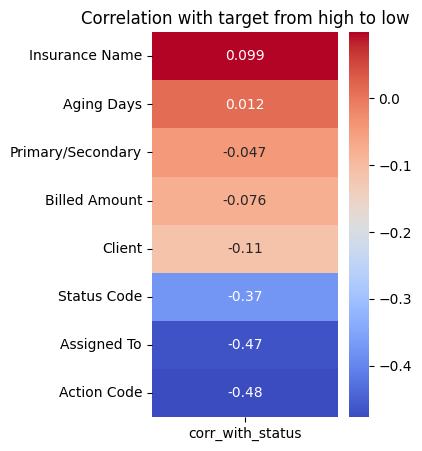

In [11]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder



cat_cols = X.select_dtypes(include='object').columns
X[cat_cols] = OrdinalEncoder().fit_transform(X[cat_cols]) # encoded the X 

# encode target
y_enc = LabelEncoder().fit_transform(y)

# correlation with target
corr_with_target = X.corrwith(pd.Series(y_enc)).sort_values(ascending=False)


plt.figure(figsize=(3, 5))
sns.heatmap(corr_with_target.to_frame(name='corr_with_status'),
            annot=True, cmap='coolwarm')
plt.title("Correlation with target from high to low")
plt.show()


Scaling the features

In [12]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()

X_scaled = scaler.fit_transform(X) # X_scaled is an array now

X = pd.DataFrame(X_scaled, columns=X.columns) # Converting X to dataframe

X.head()


,Client,Aging Days,Insurance Name,Billed Amount,Primary/Secondary,Status Code,Action Code,Assigned To
0,-0.116475,-1.242823,0.827138,-0.587150,-1.061913,0.399008,-0.457745,-1.434367
1,0.838240,0.359589,-1.631922,-1.111736,0.941697,-0.974250,0.283972,0.271367
2,0.838240,-1.700655,-1.184820,1.499064,-1.061913,1.619681,1.237608,0.995011
3,0.838240,0.130673,-1.184820,1.391872,-1.061913,-1.050542,-1.411381,0.995011
4,0.838240,1.675855,0.380037,-0.706867,-1.061913,1.619681,1.237608,0.995011


Splitting Data 

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, test_size=0.3, random_state=2)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(140, 8)
(60, 8)
(140,)
(60,)


Training the Model

In [47]:
from sklearn.ensemble import RandomForestClassifier

rfmodel = RandomForestClassifier(n_estimators=1200, random_state=2)

rfmodel.fit(X_train, y_train) # fitting our train data

y_pred = rfmodel.predict(X_test) # putting our test data to get the prediction

print(y_pred)


['No response' 'Pending' 'No response' 'Pending' 'Error' 'Denied' 'Denied'
 'No response' 'No response' 'Denied' 'Error' 'Error' 'Denied' 'Denied'
 'Denied' 'Claim at insurance' 'Claim at insurance' 'No response'
 'Pending' 'Denied' 'Denied' 'Denied' 'Claim at insurance'
 'Claim at insurance' 'Pending' 'Claim at insurance' 'No response'
 'Denied' 'Claim at insurance' 'Pending' 'Claim at insurance'
 'Claim at insurance' 'Pending' 'Error' 'Claim at insurance' 'Error'
 'Denied' 'Claim at insurance' 'Denied' 'Denied' 'Denied'
 'Claim at insurance' 'Pending' 'No response' 'Claim at insurance'
 'Denied' 'No response' 'Pending' 'Denied' 'No response' 'Denied'
 'Claim at insurance' 'Error' 'Claim at insurance' 'Denied' 'No response'
 'Denied' 'Claim at insurance' 'Denied' 'Denied']


In [48]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# prediction
y_pred = rfmodel.predict(X_test)

# accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# detailed report (precision, recall, f1)
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

Accuracy: 0.7
Confusion Matrix:
 [[14  0  0  0  0]
 [ 0  9  0  4  0]
 [ 0  0  6  0  0]
 [ 0  7  0  5  0]
 [ 1  5  0  1  8]]
Classification Report:
                     precision    recall  f1-score   support

Claim at insurance       0.93      1.00      0.97        14
            Denied       0.43      0.69      0.53        13
             Error       1.00      1.00      1.00         6
       No response       0.50      0.42      0.45        12
           Pending       1.00      0.53      0.70        15

          accuracy                           0.70        60
         macro avg       0.77      0.73      0.73        60
      weighted avg       0.76      0.70      0.70        60



Testing the model on sample data 

In [50]:
sample = pd.DataFrame([{
    'Client': 'ABC',
    'Aging Days': 120,
    'Insurance Name': 'UHC',
    'Billed Amount': 4500.0,
    'Primary/Secondary': 'Primary',
    'Status Code': 'Pending Follow-up',
    'Action Code': 'Follow up with Insurance',
    'Assigned To': 'Billing Team',
}])

sample.head()

,Client,Aging Days,Insurance Name,Billed Amount,Primary/Secondary,Status Code,Action Code,Assigned To
0,ABC,120,UHC,4500.0,Primary,Pending Follow-up,Follow up with Insurance,Billing Team


In [51]:
#encoding
cat_cols = sample.select_dtypes(include='object').columns

for col in cat_cols:
    value_map = sample[col].value_counts(normalize=True)
    sample[col] = sample[col].map(value_map)

sample.head()

,Client,Aging Days,Insurance Name,Billed Amount,Primary/Secondary,Status Code,Action Code,Assigned To
0,1.0,120,1.0,4500.0,1.0,1.0,1.0,1.0


In [53]:
#scaling
sample_scaled = scaler.transform(sample)

sample = pd.DataFrame(sample_scaled, columns=sample.columns)

sample.head()

,Client,Aging Days,Insurance Name,Billed Amount,Primary/Secondary,Status Code,Action Code,Assigned To
0,-1.0,-120.0,-1.0,-4500.0,-1.0,-1.0,-1.0,-1.0


In [63]:
result = rfmodel.predict(sample)
print(result)

['No response']
